## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [2]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function

OBJECT_NAME = "LAMP_NE"
EXPOSURE = 10000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name, exp_time=200):
    bias_folder = f"{object_name}/BIAS_{exp_time}"
    bias_files = os.listdir(bias_folder)
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)), dtype=np.float32)

    for i, bias in tqdm(enumerate(bias_files)): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data.astype(np.float32)

    master_bias = np.median(biases, axis=2)
    return master_bias

In [4]:
MASTER_BIAS = master_bias(OBJECT_NAME)

50it [00:01, 27.36it/s]


### Master bias visualisation

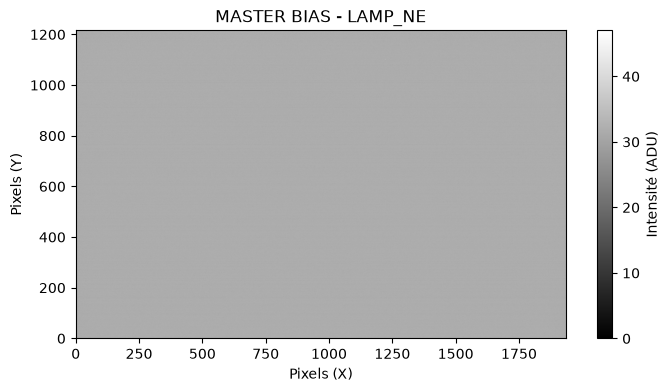

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER BIAS - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **3. Creating the master dark**

We will also remove the master bias from each of them, as to obtain as thermically pure master dark

### Function

s important pour la suite (La soustraction sur tes "Lights")

Puisque ton `master_dark` est maintenant "pur" (sans le bruit de lecture), l'équation de prétraitement pour tes images d'objets (*Light frames*) change.

Au lieu de faire simplement `Light - Master_Dark`, tu devras faire :


$$\text{Image Corrigée} = \text{Light} - \text{Master Bias} - \text{Master Dark}$$

Cette méthode est la plus rigoureuse car elle te permettra plus tard (si tu le souhaites) de "scaler" ton dark. Par exemple, si tu as un Master Dark de 60s mais une image d'objet de 30s, tu pourras faire : `Light - Master_Bias - (Master_Dark * 0.5)`. C'est ultra pratique en astronomie professionnelle ou pour de la recherche d'exoplanètes où les temps de pose varient !

In [6]:
def master_dark(object_name,exp_time, master_bias):
    dark_folder = f"TRUE_DARK_{exp_time}_1/DARK_{exp_time}"
    dark_files = os.listdir(dark_folder)
    darks = np.zeros((MAX_H,MAX_W,len(dark_files)), dtype=np.float32)

    for i, dark in tqdm(enumerate(dark_files)): # loop for each bias in the bias folder
        with fits.open(f"{dark_folder}/{dark}") as hdul: # open fits file
            darks[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    master_dark = np.median(darks, axis=2)
    return master_dark

In [7]:
MASTER_DARK = master_dark(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

50it [00:01, 27.13it/s]


### Master dark visualization

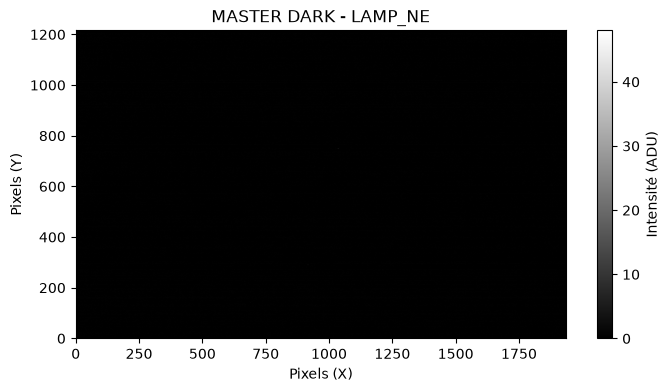

In [8]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_DARK, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER DARK - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **4. Creating the master flat**

Similarly to the master dark, we will substract the bias for each flat frame

### Function

In [9]:
def master_flat(object_name,exp_time, master_bias):
    flat_folder = f"TEST_FLAT/FLAT_{exp_time}"
    flat_files = os.listdir(flat_folder)
    flats = np.zeros((MAX_H,MAX_W,len(flat_files)), dtype=np.float32)

    for i, flat in tqdm(enumerate(flat_files)): # loop for each bias in the bias folder
        with fits.open(f"{flat_folder}/{flat}") as hdul: # open fits file
            flats[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    raw_master_flat = np.median(flats, axis=2)

    master_flat = raw_master_flat / np.median(raw_master_flat) # correct for the vignetting/dust without changing the actual value of each pixel
    return master_flat

In [10]:
MASTER_FLAT = master_flat(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

20it [00:00, 41.20it/s]


### Master flat visualization

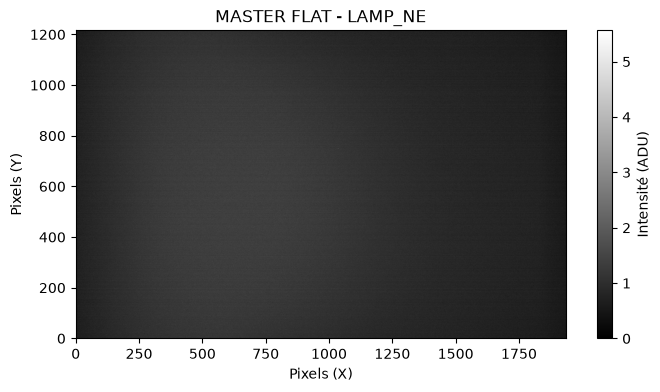

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER FLAT - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **5. Creating the final corrected image**

### Function

In [12]:
def master_science(object_name, exp_time, m_bias, m_dark, m_flat):
    science_folder = f"{object_name}/SCIENCE_{exp_time}"
    science_files = os.listdir(science_folder)
    sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)

    for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
        with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
            sciences[:,:,i] = hdul[0].data.astype(np.float32) - m_bias.astype(np.float32)
            header = hdul[0].header

    master_science_uncorrected = np.median(sciences, axis=2)
    master_science = (np.median(sciences, axis=2) - m_dark) / m_flat

    return master_science,master_science_uncorrected, header

In [13]:
MASTER_SCIENCE, MASTER_SCIENCE_UNCORR, header = master_science(OBJECT_NAME, EXPOSURE, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

0it [00:00, ?it/s]

50it [00:01, 29.32it/s]


### Master science visualisation

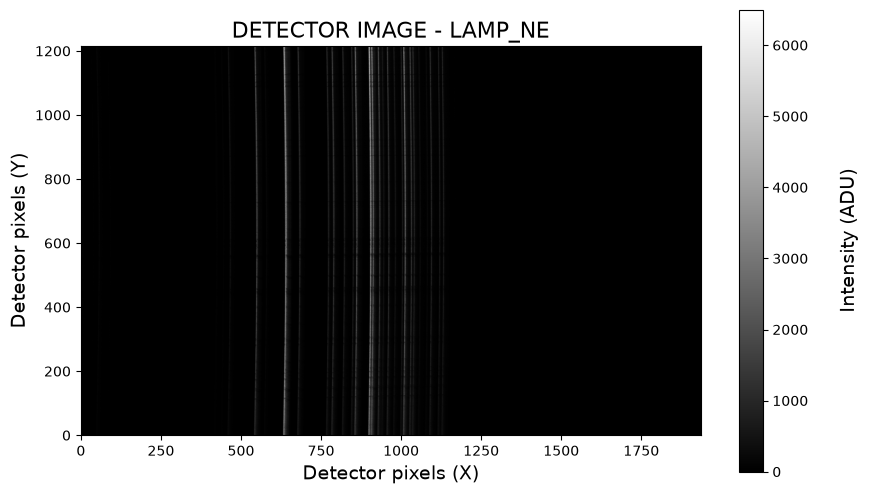

In [15]:
fig, ax = plt.subplots(figsize=(10,6))

im = ax.imshow((MASTER_SCIENCE), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax.set_title(f"DETECTOR IMAGE - {OBJECT_NAME}", fontsize=16)
ax.set_xlabel("Detector pixels (X)", fontsize=14)
ax.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar = fig.colorbar(im, ax=ax, label="\nIntensity (ADU)")
cbar.set_label('\nIntensity (ADU)', fontsize=14)
plt.show()

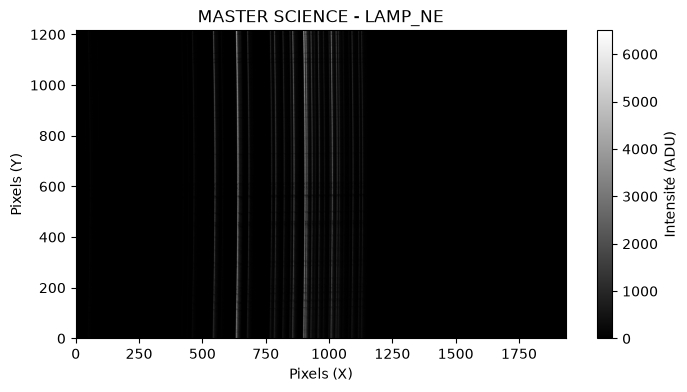

In [16]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_SCIENCE, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER SCIENCE - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

### <span style="color:red">TODO : Think if I should create a FITS file for the final science calibrated image</span>.

## **6. Spectra extraction**

### Function

> **The spectra array needs to be reverse, as the +1 order on the detector is red on left and blue on right**

In [16]:
def spectra_plot(m_science, header, log=False, ylines=[0,607,1215],xmin=0,xmax=1936):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

    # m_science = header
    for line in ylines:
        if log:
            ax1.plot(np.log10(m_science[line,:][::-1] + 1 + np.abs(np.min(m_science[line,:][::-1]))),marker='.',ls='',label=f'Line : {line}') # reverse
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)
        else:
            ax1.plot(m_science[line,:][::-1],marker='.',ls='',label=f'Line : {line}')
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)

    # ax1.set_title(f"FITS - {header['DATE-OBS']}\n EXP : {header['EXPTIME']} - GAIN : {header['GAIN']}\n OBJ : {header['OBJECT']}- RA : {header['RA']} - DEC : {header['DEC']}")
    ax1.set_xlabel("Pixels (X)")
    ax1.set_ylabel("Intensity (ADU)")
    ax1.legend()
    

    ax1.grid(ls='--',c='lightgrey')
    ax1.set_axisbelow(True)
    ax1.set_xlim(xmin,xmax)



    im = ax2.imshow(m_science, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
    # On trace la ligne rouge horizontale là où la coupe est faite
    
    ax2.set_title("Detector image (2D)")
    ax2.set_xlabel("Pixels (X)")
    ax2.set_ylabel("Pixels (Y)")
    ax2.legend(loc='upper right')

    fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

    fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
                 f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
                 fontsize=12, y=0.98)

    plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
    plt.show()

In [17]:
# spectra_plot(MASTER_SCIENCE, header, False, [0,600,1200],1700,1720)

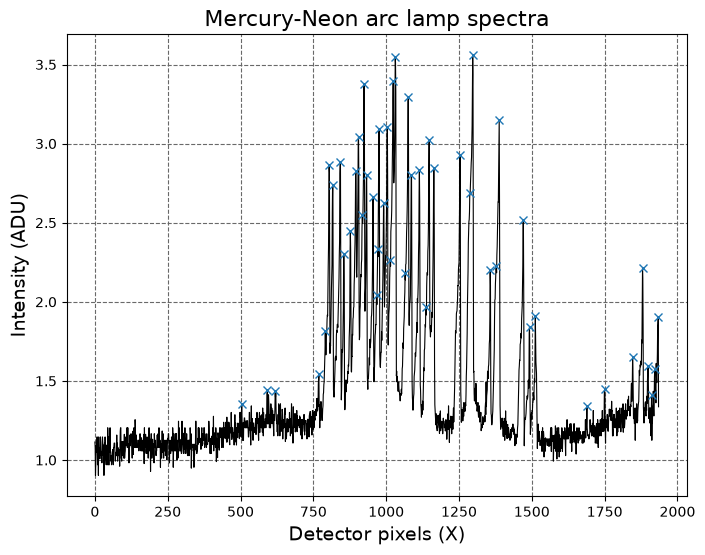

In [17]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt


data = MASTER_SCIENCE[300,:][::-1]
x, y = np.arange(1936), data

peaks, _ = find_peaks(y, height=10, distance=3, prominence=(10,10000))#,threshold=100)

fig, ax = plt.subplots(figsize=(8,6))
# mask=[0,2,3,4,5,7,8,9]
# ax.plot(x,y,c='black',lw=0.8)#,marker='.')
ax.plot(x,np.log10(y),c='black',lw=0.8)#,marker='.')

ax.plot(peaks, np.log10(y[peaks]), "x")
# ax.plot(peaks[mask], y[peaks][mask], "x")
# ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
# ax.axvline(x=771,ls='--',alpha=0.7)
# ax.axvline(x=780,ls='--',alpha=0.7)
ax.grid(ls='--',c='dimgrey')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
# ax.set_title(f'{OBJECT_NAME} SPECTRA\n')
ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)

plt.show()
# def gaussian_absorption(x, y0, A, mu, sigma):
#     return y0 + A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
# peaks[mask]

In [19]:
# np.set_printoptions(threshold=np.inf)
# print(y)

In [ ]:
# from scipy.signal import find_peaks_cwt

# fig, ax = plt.subplots(figsize=(9,6))

# widths = np.arange(1,20)

# y_test = MASTER_SCIENCE[500,:][::-1]
# # a = find_peaks_cwt(MASTER_SCIENCE[300,:][::-1],widths,min_snr=3, noise_perc=5,gap_thresh=2)
# peaks, props = find_peaks(y_test, prominence=10, distance=5)
# ax.grid(ls='--',c='dimgrey')
# ax.plot(x,(np.log10(y_test)))
# # ax.plot(peaks,(y[peaks]), "x")
# ax.set_title(f"Finding peak of {OBJECT_NAME} w/ 'find_peaks_cwt'")
# ax.set_ylabel('Intensity (ADU)')
# ax.set_xlabel('Detector pixels (X)')

{365.02: None,
366.33: None,


404.66: None,
435.84: None,
546.07: None,
576.96: None,
579.07: None,

724.52: None}

## **7. Visualazing the peak finding parameters**

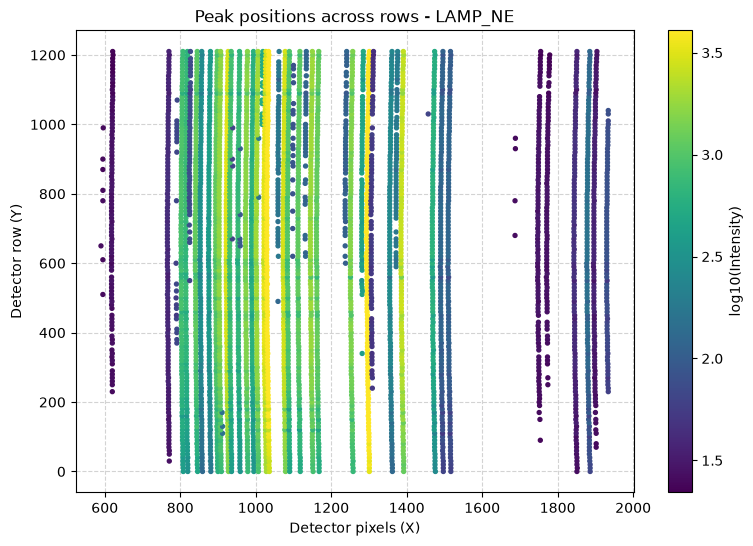

In [18]:
from scipy.signal import find_peaks
import numpy as np

n_rows = MASTER_SCIENCE_UNCORR.shape[0] # nombre de rangées horizontales
rows = np.arange(0, n_rows, 10)  # échantillonne toutes les 10 lignes, ajuste selon besoin

all_peaks = []   # liste de (row_index, x_pixel, intensity)
for row in rows:
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1] # on remet le spectre avec bleu a gauche et rouge a droite (augmentation longueur d'onde de gauche a droite)
    peaks, props = find_peaks(y_row, prominence=10, distance=5)
    for p in peaks:
        all_peaks.append((row, p, y_row[p]))

all_peaks = np.array(all_peaks)  # colonnes: [row, x_pixel, intensity]

fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(all_peaks[:,1], all_peaks[:,0], c=np.log10(all_peaks[:,2]), 
                 cmap='viridis', s=8)
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Peak positions across rows - {OBJECT_NAME}")
ax.grid(ls='--',c='lightgrey')
ax.set_axisbelow(True)
# ax.set_xlim(70,500)
plt.colorbar(sc, label='log10(Intensity)')

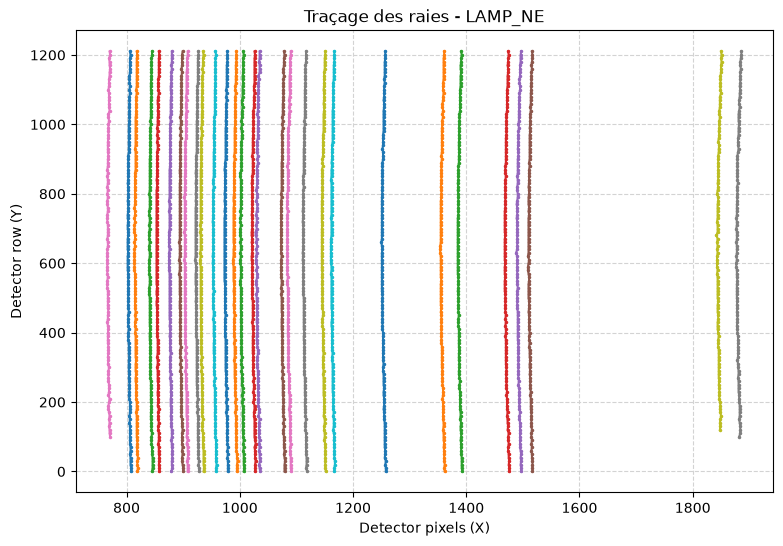

In [19]:
from collections import defaultdict

tracks = defaultdict(list)  # track_id -> liste de (row, x, intensity)
next_id = 0
last_row_peaks = {}  # x_pixel -> track_id, pour la dernière ligne traitée

tol = 3  # tolérance en pixels pour associer un pic à une raie existante

for row in rows:
    y_row = MASTER_SCIENCE[row, :][::-1]
    peaks, _ = find_peaks(y_row, prominence=10, distance=5)
    current_row_peaks = {}
    for p in peaks:
        # cherche la raie la plus proche dans la ligne précédente
        matched_id = None
        for x_prev, tid in last_row_peaks.items():
            if abs(p - x_prev) < tol:
                matched_id = tid
                break
        if matched_id is None:
            matched_id = next_id
            next_id += 1
        tracks[matched_id].append((row, p, y_row[p]))
        current_row_peaks[p] = matched_id
    last_row_peaks = current_row_peaks

# Plot chaque track avec une couleur différente
fig, ax = plt.subplots(figsize=(9,6))
for tid, pts in tracks.items():
    if len(pts) > 100:  # ignore les tracks trop courtes (probablement du bruit)
        pts = np.array(pts)
        ax.plot(pts[:,1], pts[:,0], '.-', ms=3, label=f'raie {tid}')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Traçage des raies - {OBJECT_NAME}")
ax.grid(ls='--',c='lightgrey')

to retrieve each line correctly, it should only keep the on with the same intensity give or take

## **8. Fitting the parabolas**

In [20]:
import numpy as np

fits = {}  # track_id -> (coeffs, rows_used, x_used)

for tid, pts in tracks.items():
    if len(pts) < 100:  # ignore les tracks trop courtes / pas assez de points
        continue
    pts = np.array(pts)
    rows_t = pts[:, 0]
    x_t = pts[:, 1]
    insty = pts[:,2]
    
    coeffs = np.polyfit(rows_t, x_t, deg=2)  # [a, b, c] pour a*row^2 + b*row + c
    fits[tid] = (coeffs, rows_t, x_t,insty)

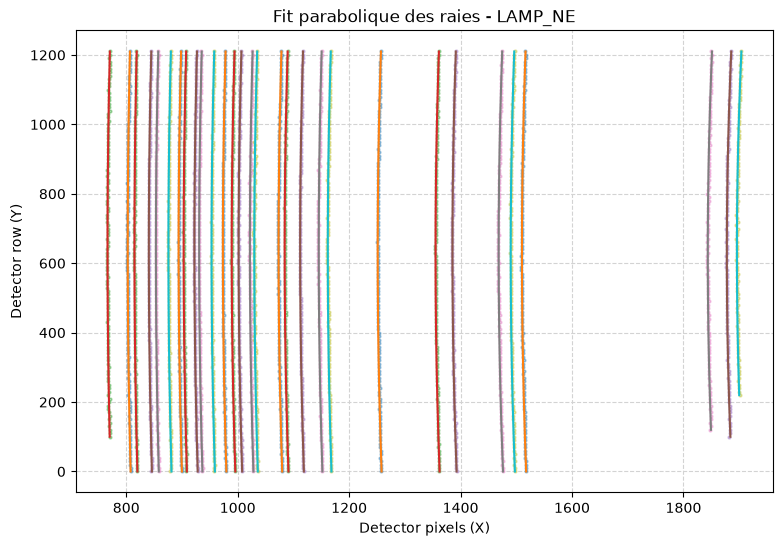

In [21]:
fig, ax = plt.subplots(figsize=(9,6))

for tid, (coeffs, rows_t, x_t, insty) in fits.items():
    # sc = ax.scatter(x_t, rows_t, c=np.log10(insty), s=12, cmap='viridis', alpha=0.5)
    sc = ax.plot(x_t, rows_t,'.', ms=4, alpha=0.4)
    row_fine = np.linspace(rows_t.min(), rows_t.max(), 200)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-', lw=1.5, label=f'raie {tid}')

ax.grid(ls='--',c='lightgrey')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Fit parabolique des raies - {OBJECT_NAME}")
plt.show()
# cbar = fig.colorbar(sc, ax=ax, label='log10(Intensity)')
# ax.legend(fontsize=7)

In [ ]:

track_mean_x = {tid: np.mean(x_t) for tid, (coeffs, rows_t, x_t, rms) in fits.items()}

# Trie les tracks par position x croissante
sorted_tracks = sorted(track_mean_x.items(), key=lambda kv: kv[1])
print(sorted_tracks) 

735.8962
743.7195
# track_to_wavelength = {
#     #sorted_tracks[7][0]: 365.02,
#     #sorted_tracks[6][0]: 366.33,
#     sorted_tracks[0][0]: 404.66,
#     sorted_tracks[1][0]: 435.84,
#     sorted_tracks[2][0]: 546.07,
#     sorted_tracks[3][0]: 576.96,
#     sorted_tracks[4][0]: 579.07,
#     sorted_tracks[5][0]: 724.59,
#     #sorted_tracks[5][0]: 640.20,
# }

[(259, np.float64(767.7232142857143)), (8, np.float64(804.1639344262295)), (10, np.float64(816.2704918032787)), (13, np.float64(842.1803278688525)), (14, np.float64(854.7868852459017)), (15, np.float64(877.3360655737705)), (16, np.float64(895.6967213114754)), (17, np.float64(904.7377049180328)), (19, np.float64(924.0573770491803)), (20, np.float64(932.5901639344262)), (22, np.float64(954.8688524590164)), (24, np.float64(975.2786885245902)), (25, np.float64(991.2049180327868)), (26, np.float64(1003.5573770491803)), (29, np.float64(1023.7786885245902)), (30, np.float64(1031.72131147541)), (32, np.float64(1075.3196721311476)), (33, np.float64(1086.344262295082)), (35, np.float64(1114.0737704918033)), (37, np.float64(1147.4344262295083)), (39, np.float64(1163.704918032787)), (41, np.float64(1253.3934426229507)), (45, np.float64(1357.311475409836)), (47, np.float64(1387.6967213114754)), (48, np.float64(1470.7295081967213)), (49, np.float64(1492.295081967213)), (50, np.float64(1512.5)), (312

In [79]:
# HGNE_WAVELENGTH = np.array([365.02,366.33,404.66,435.84, 546.07,576.96,579.07,724.52])

HGNE_WAVELENGTH = {#365.02: None,
                   #366.33: None,
                   404.66: None,
                   435.84: None,
                   546.07: None,
                   576.96: None,
                   579.07: None,
                   724.52: None}

track_mean_x = {tid: np.mean(x_t) for tid, (coeffs, rows_t, x_t, rms) in fits.items()}

# Trie les tracks par position x croissante
sorted_tracks = sorted(track_mean_x.items(), key=lambda kv: kv[1])
print(sorted_tracks) 


track_to_wavelength = {
    #sorted_tracks[7][0]: 365.02,
    #sorted_tracks[6][0]: 366.33,
    sorted_tracks[0][0]: 404.66,
    sorted_tracks[1][0]: 435.84,
    sorted_tracks[2][0]: 546.07,
    sorted_tracks[3][0]: 576.96,
    sorted_tracks[4][0]: 579.07,
    sorted_tracks[5][0]: 724.59,
    #sorted_tracks[5][0]: 640.20,
}

[(0, np.float64(84.43442622950819)), (3, np.float64(204.37704918032787)), (4, np.float64(424.4672131147541)), (9, np.float64(770.2295081967213)), (10, np.float64(778.8770491803278)), (11, np.float64(1712.188524590164))]


In [80]:
def get_x_for_row(track_id, row):
    coeffs = fits[track_id][0]
    return np.polyval(coeffs, row)

n_rows = MASTER_SCIENCE_UNCORR.shape[0]
all_rows = np.arange(n_rows)

# Table (row, x_pixel, wavelength) pour toutes les raies identifiées
calib_points = []
for tid, wl in track_to_wavelength.items():
    for row in all_rows:
        x_val = get_x_for_row(tid, row)
        calib_points.append((row, x_val, wl))

calib_points = np.array(calib_points)

In [81]:
degree = 2  # ou 3 selon la non-linéarité du spectrographe

wavelength_fits = {}  # row -> coeffs

for row in all_rows:
    mask = calib_points[:, 0] == row
    x_row = calib_points[mask, 1]
    wl_row = calib_points[mask, 2]
    
    if len(x_row) >= degree + 1:  # assez de points pour le fit
        coeffs_wl = np.polyfit(x_row, wl_row, deg=degree)
        wavelength_fits[row] = coeffs_wl

In [82]:
n_cols = MASTER_SCIENCE_UNCORR.shape[1]
wavelength_map = np.full((n_rows, n_cols), np.nan)

x_pixels = np.arange(n_cols)

for row, coeffs_wl in wavelength_fits.items():
    wavelength_map[row, :] = np.polyval(coeffs_wl, x_pixels)

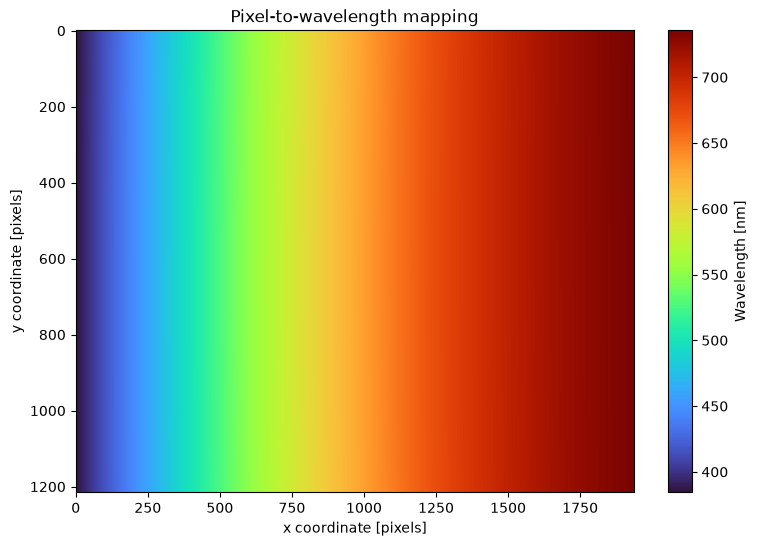

In [83]:
fig, ax = plt.subplots(figsize=(9,6))
im = ax.imshow(wavelength_map, aspect='auto', cmap='turbo', origin='upper')
ax.set_xlabel('x coordinate [pixels]')
ax.set_ylabel('y coordinate [pixels]')
ax.set_title('Pixel-to-wavelength mapping')
plt.colorbar(im, label='Wavelength [nm]')

In [84]:
degree = 2  # ou 3 selon la non-linéarité du spectrographe

wavelength_fits = {}  # row -> coeffs

for row in all_rows:
    mask = calib_points[:, 0] == row
    x_row = calib_points[mask, 1]
    wl_row = calib_points[mask, 2]
    
    if len(x_row) >= degree + 1:  # assez de points pour le fit
        coeffs_wl = np.polyfit(x_row, wl_row, deg=degree)
        wavelength_fits[row] = coeffs_wl

ValueError: too many values to unpack (expected 3, got 4)

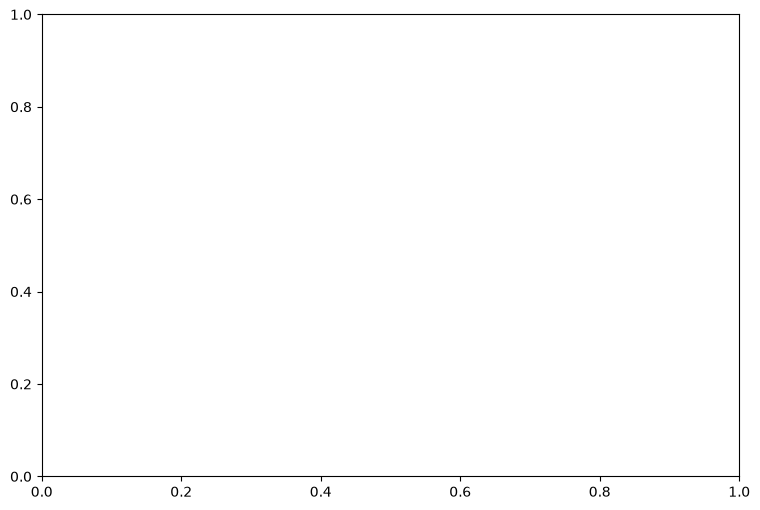

In [85]:
fig, ax = plt.subplots(figsize=(9,6))

for tid, (coeffs, rows_t, x_t) in fits.items():
    x_pred = np.polyval(coeffs, rows_t)
    residuals = x_t - x_pred
    ax.plot(rows_t, residuals, '.', ms=4, label=f'raie {tid}')

ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Detector row (Y)')
ax.set_ylabel('Résidu (pixels)')
ax.set_title('Résidus des fits paraboliques')
# ax.legend(fontsize=7)

In [ ]:
good_fits = {}
for tid, (coeffs, rows_t, x_t) in fits.items():
    x_pred = np.polyval(coeffs, rows_t)
    rms = np.sqrt(np.mean((x_t - x_pred)**2))
    if rms < 1.0:  # seuil à ajuster selon ta précision attendue
        good_fits[tid] = (coeffs, rows_t, x_t, rms)

print(f"{len(good_fits)}/{len(fits)} raies avec un fit propre")

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))

for tid, (coeffs, rows_t, x_t, rms) in good_fits.items():
    ax.plot(x_t, rows_t, '.', ms=4, alpha=0.5)  # points détectés
    row_fine = np.linspace(rows_t.min(), rows_t.max(), 200)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-', lw=1.5, label=f'raie {tid} (rms={rms:.2f})')

ax.grid(ls='--', c='dimgrey')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Fits paraboliques valides - {OBJECT_NAME}")
# ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(9,6))
colors = cm.viridis(np.linspace(0, 1, len(good_fits)))

for (tid, (coeffs, rows_t, x_t, rms)), c in zip(good_fits.items(), colors):
    ax.plot(x_t, rows_t, '.', ms=4, alpha=0.4, color=c)
    row_fine = np.linspace(rows_t.min(), rows_t.max(), 200)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-', lw=1.5, color=c)

ax.grid(ls='--', c='dimgrey')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Fits paraboliques valides ({len(good_fits)} raies) - {OBJECT_NAME}")

In [ ]:
rms_values = [v[3] for v in good_fits.values()]
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(rms_values, bins=20)
ax.set_xlabel('RMS résidu (pixels)')
ax.set_ylabel('Nombre de raies')
ax.set_title('Distribution des RMS des fits valides')

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
ax.imshow(MASTER_SCIENCE[:, ::-1], aspect='auto', cmap='gray',
          vmin=np.percentile(MASTER_SCIENCE, 5),
          vmax=np.percentile(MASTER_SCIENCE, 99))

for tid, (coeffs, rows_t, x_t, rms) in good_fits.items():
    row_fine = np.linspace(rows_t.min(), rows_t.max(), 200)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, 'r-', lw=1)

ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Fits superposés sur l'image - {OBJECT_NAME}")

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
ax.imshow(MASTER_SCIENCE_UNCORR[:, ::-1], aspect='auto', cmap='gray', 
          vmin=np.percentile(MASTER_SCIENCE_UNCORR, 5), 
          vmax=np.percentile(MASTER_SCIENCE_UNCORR, 99))
ax.scatter(all_peaks[:,1], all_peaks[:,0], c='red', s=3, marker='.')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Peaks overlaid on detector image - {OBJECT_NAME}")

In [ ]:
from collections import defaultdict

tracks = defaultdict(list)  # track_id -> liste de (row, x, intensity)
next_id = 0
last_row_peaks = {}  # x_pixel -> track_id, pour la dernière ligne traitée

tol = 5  # tolérance en pixels pour associer un pic à une raie existante

for row in rows:
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
    peaks, _ = find_peaks(y_row, prominence=10, distance=5)
    current_row_peaks = {}
    for p in peaks:
        # cherche la raie la plus proche dans la ligne précédente
        matched_id = None
        for x_prev, tid in last_row_peaks.items():
            if abs(p - x_prev) < tol:
                matched_id = tid
                break
        if matched_id is None:
            matched_id = next_id
            next_id += 1
        tracks[matched_id].append((row, p, y_row[p]))
        current_row_peaks[p] = matched_id
    last_row_peaks = current_row_peaks

# Plot chaque track avec une couleur différente
fig, ax = plt.subplots(figsize=(9,6))
for tid, pts in tracks.items():
    if len(pts) > 5:  # ignore les tracks trop courtes (probablement du bruit)
        pts = np.array(pts)
        ax.plot(pts[:,1], pts[:,0], '.-', ms=3, label=f'raie {tid}')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Traçage des raies - {OBJECT_NAME}")

In [ ]:
ylines = [200,400,600,800,1000,1200]
for yline in ylines:
    peaks, prop = find_peaks(yline, height=10, distance=3, prominence=(10,10000))#,threshold=100)


In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt


data = MASTER_SCIENCE[600,:][::-1]
x, y = np.arange(1936), data

peaks, _ = find_peaks(y, height=10, distance=3, prominence=10)

fig, ax = plt.subplots(figsize=(4,6))
# mask=[0,2,3,4,5,7,8,9]
ax.plot(x,y,c='black',marker='.')
ax.plot(peaks, y[peaks], "x")
# ax.plot(peaks[mask], y[peaks][mask], "x")
# ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
ax.axvline(x=768,ls='--',alpha=0.7)
ax.axvline(x=777,ls='--',alpha=0.7)
ax.grid(ls='--',c='dimgrey')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
ax.set_title(f'Mercury-Neon arc lamp spectra\n(Mercury Doublet)',fontsize=16)
ax.set_xlim(757,787)
ax.set_ylim(ymax=2500)
ax.set_axisbelow(True)
plt.show()
# def gaussian_absorption(x, y0, A, mu, sigma):
#     return y0 + A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
# peaks[mask]

|pixel|lambda|
|:---|:---|
|84|404.66|
|89|407.78|
|188|433.92|
|195|434.75|
|204|435.84|
|642|546.07|
|768|576.96|
|777|579.07|





In [ ]:
x_spectra = peaks[mask]# [84,  89, 188, 195, 204, 642, 768, 777]
y_spectra = [404.66,407.78,433.92,434.75,435.84,546.07,576.96,579.07]


# fig, ax = plt.subplots(figsize=(8,6))
# ax.scatter(x_spectra,y_spectra)
# ax.grid(ls='--',c='lightgrey')
# ax.set_xlabel('Pixels')
# ax.set_ylabel("Longueur d'onde [nm]")
# ax.set_title("Relation entre pixel et longueur d'onde pour lampe HgNe")

coeffs = np.polyfit(x_spectra, y_spectra, deg=2)

# 3. Génération de la droite de régression
pixels_fit = np.linspace(50, 800, 1000)
lambdas_fit = np.polyval(coeffs, pixels_fit)

chi_squared = np.sum((np.polyval(coeffs, x_spectra) - y_spectra) ** 2) / (len(y_spectra)-4)

# 4. Le tracé
plt.figure(figsize=(8, 6))
plt.scatter(x_spectra, y_spectra, color='tab:blue', s=50, label='Tes repères (HgNe)', zorder=3)
plt.plot(pixels_fit, lambdas_fit, color='tab:red', linestyle='--', 
        # label=f'Modèle ordre 3 (Fit)\nLambda = {coeffs[0]:.3E} * px**3\n+ {coeffs[1]:.3E}*px**2\n+ {coeffs[2]:.3E}*px\n+ {coeffs[3]:.3E}\nreduced chi2 : {chi_squared:.2f}', zorder=2)
        label=f'Modèle ordre 2 (Fit)\nLambda = {coeffs[0]:.3E} * px**2\n+ {coeffs[1]:.3E}*px\n+ {coeffs[2]:.3E}\nreduced chi2 : {chi_squared:.2f}', zorder=2)


plt.title("Relation entre pixel et longueur d'onde pour lampe HgNe")
plt.xlabel("Pixels")
plt.ylabel("Longueur d'onde [nm]")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# print(f"Équation : Lambda = {coeffs[0]:.5f} * Pixel + {coeffs[1]:.2f}")

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# Le modèle : A sera positif ici
def gaussian_emission(x, y0, A, mu, sigma):
    return y0 + A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

resultats = []
largeur_fenetre = 20  # On isole bien le pic

for idx in peaks:
    # Fenêtrage
    idx_min = max(0, idx - largeur_fenetre)
    idx_max = min(len(x), idx + largeur_fenetre)
    
    x_raie = x[idx_min:idx_max]
    y_raie = x[idx_min:idx_max]
    
    # Estimations initiales adaptées à l'émission
    y0_guess = np.min(y_raie)          # Fond proche de 0
    A_guess = np.max(y_raie) - y0_guess # Hauteur du pic (positif)
    mu_guess = x[idx]              # Position de la croix
    sigma_guess = 3                     # Tes pics ont l'air très fins
    
    p0 = [y0_guess, A_guess, mu_guess, sigma_guess]
    
    # On force les paramètres à rester physiquement logiques (Optionnel mais recommandé)
    # bounds = ([min_y0, min_A, min_mu, min_sigma], [max_y0, max_A, max_mu, max_sigma])
    bounds = ([0, 0, mu_guess-5, 0.1], [500, 5000, mu_guess+5, 10])
    
    try:
        popt, pcov = curve_fit(gaussian_emission, x_raie, y_raie, p0=p0, bounds=bounds)
        resultats.append(popt)
        print(f"Raie calibrée à la position x = {popt[2]:.2f}")
    except RuntimeError:
        print(f"Le fit a échoué pour le pic à x = {mu_guess:.2f}")

---

In [ ]:
import astropy.units as u
import specutils
from specutils import Spectrum, SpectralRegion, analysis, manipulation, fitting
from astropy.visualization import quantity_support
specutils.__version__

In [ ]:
from scipy.optimize import curve_fit

# def gaussian(x, amplitude, center, sigma, offset):
#     """Gaussienne avec offset (continuum local)."""
#     return amplitude * np.exp(-0.5 * ((x - center) / sigma)**2) + offset

# def d_gaussian(x, amplitude_1, center_1, sigma_1, offset_1,amplitude_2, center_2, sigma_2, offset_2):
#     """Gaussienne avec offset (continuum local)."""
#     g_1 = amplitude_1 * np.exp(-0.5 * ((x - center_1) / sigma_1)**2) + offset_1
#     g_2 = amplitude_2 * np.exp(-0.5 * ((x - center_2) / sigma_2)**2) + offset_2
#     return g_1+g_2

def d_gaussian(x, amp1, cent1, sig1, amp2, cent2, sig2, offset):
    g1 = amp1 * np.exp(-0.5 * ((x - cent1) / sig1)**2)
    g2 = amp2 * np.exp(-0.5 * ((x - cent2) / sig2)**2)
    return g1 + g2 + offset

# Pour tracer les composantes individuelles après coup
def gaussian(x, amp, cent, sig, offset):
    return amp * np.exp(-0.5 * ((x - cent) / sig)**2) + offset


initial_guess_peaks = [800, 768, 5,1,  800, 777,5,1]
# bnd = (())


x = np.linspace(0,1935,1936)
print(x)
y = (MASTER_SCIENCE[600,:][::-1])

popt, pcov = curve_fit(d_gaussian,x,y,p0=initial_guess_peaks)
yfit = d_gaussian(x,*popt)

yfit1 = gaussian(x,*popt[0:4])
yfit2 = gaussian(x,*popt[4:8])

plt.plot(x,y)
plt.plot(x,yfit)
plt.plot(x,yfit1)
plt.plot(x,yfit2)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Redéfinition propre de la double gaussienne (un seul offset)
def d_gaussian(x, amp1, cent1, sig1, amp2, cent2, sig2, offset):
    g1 = amp1 * np.exp(-0.5 * ((x - cent1) / sig1)**2)
    g2 = amp2 * np.exp(-0.5 * ((x - cent2) / sig2)**2)
    return g1 + g2 + offset

# Pour tracer les composantes individuelles après coup
def gaussian(x, amp, cent, sig, offset):
    return amp * np.exp(-0.5 * ((x - cent) / sig)**2) + offset

# 2. Extraction des données globales
x_full = np.arange(1936)
y_full = MASTER_SCIENCE[600, :][::-1]

# 3. CRUCIAL : On restreint l'ajustement à la zone des pics (entre X=750 et X=780)
mask = (x_full >= 750) & (x_full <= 780)
x_crop = x_full[mask]
y_crop = y_full[mask]

# 4. Estimations initiales réalistes basées sur ton graphique zoomé
# [amp1, cent1, sig1, amp2, cent2, sig2, offset_global]
initial_guess = [700, 768, 2, 850, 777, 2, 20]

# 5. Ajustement uniquement sur la zone fenêtrée
popt, pcov = curve_fit(d_gaussian, x_crop, y_crop, p0=initial_guess)

# 6. Extraction des paramètres pour le tracé
amp1, cent1, sig1, amp2, cent2, sig2, offset_opt = popt

# Génération des courbes sur la zone cropée pour vérification visuelle
x_fit = np.linspace(750, 780, 200)
y_fit_total = d_gaussian(x_fit, *popt)
y_fit1 = gaussian(x_fit, amp1, cent1, sig1, offset_opt)
y_fit2 = gaussian(x_fit, amp2, cent2, sig2, offset_opt)

# 7. Affichage du résultat
plt.figure(figsize=(8, 5))
plt.scatter(x_crop, y_crop, label="Données (spectre)", color="black", s=10)
plt.plot(x_fit, y_fit_total, label="Ajustement global", color="red", lw=2)
plt.plot(x_fit, y_fit1, "--", label="Pic 1 (Hg/Ne ?)", color="blue", alpha=0.7)
plt.plot(x_fit, y_fit2, "--", label="Pic 2", color="orange", alpha=0.7)

plt.xlabel("Pixels (X)")
plt.ylabel("Intensité (ADU)")
plt.title("Ajustement de la double raie d'émission")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(f"Centre du premier pic : {cent1:.2f} pixels")
print(f"Centre du second pic  : {cent2:.2f} pixels")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Configuration du style pour publication (A&A / ApJ style)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 14
})

# [Insère ici tes définitions de fonctions d_gaussian et gaussian]

# ... (Même étape de crop/fit que précédemment) ...
popt, pcov = curve_fit(d_gaussian, x_crop, y_crop, p0=initial_guess)
perr = np.sqrt(np.diag(pcov)) # Incertitudes à 1-sigma

# Calcul des résidus
y_fit_at_data = d_gaussian(x_crop, *popt)
residuals = y_crop - y_fit_at_data

# --- Création de la figure double panneau ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05) # Colle les deux graphiques

# Panneau principal (Spectre et Fit)
ax1.scatter(x_crop, y_crop, color='black', s=12, facecolors='none', edgecolors='black', label='Data')
x_highres = np.linspace(750, 780, 500)
ax1.plot(x_highres, d_gaussian(x_highres, *popt), color='crimson', lw=1.5, label='Total Fit')

# Composantes individuelles en pointillés fins
amp1, cent1, sig1, amp2, cent2, sig2, offset_opt = popt
ax1.plot(x_highres, gaussian(x_highres, amp1, cent1, sig1, offset_opt), ':', color='royalblue', alpha=0.8, label='Component 1')
ax1.plot(x_highres, gaussian(x_highres, amp2, cent2, sig2, offset_opt), ':', color='darkorange', alpha=0.8, label='Component 2')

ax1.set_ylabel('Intensity (ADU)')
ax1.legend(frameon=True, facecolor='white', edgecolor='none')
ax1.tick_params(direction='in', top=True, right=True)
ax1.set_ylim(-20, 950)

# Panneau des résidus
ax2.scatter(x_crop, residuals, color='black', s=12, facecolors='none', edgecolors='black')
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Pixel (X)')
ax2.tick_params(direction='in', top=True, right=True)
ax2.set_ylim(-60, 60) # À ajuster selon ton bruit

# Sauvegarde en format vectoriel (indispensable pour les éditeurs)
# plt.savefig('doublet_calibration_fit.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print propre pour ton rapport/article
print(f"Peak 1 Position: {popt[1]:.3f} +/- {perr[1]:.3f} pix")
print(f"Peak 2 Position: {popt[4]:.3f} +/- {perr[4]:.3f} pix")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Configuration du style pour publication
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# 1. Définition d'un profil de Pseudo-Voigt unitaire (amplitude = 1)
def pseudo_voigt(x, center, fwhm, eta):
    """Profil de Pseudo-Voigt basé sur le centre et la FWHM commune."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2))) # pour la gaussienne
    gamma = fwhm / 2.0                          # pour la lorentzienne
    
    # Composante Gaussienne
    g = np.exp(-0.5 * ((x - center) / sigma)**2)
    # Composante Lorentziene
    l = 1 / (1 + ((x - center) / gamma)**2)
    
    return eta * l + (1 - eta) * g

# 2. Modèle global : 2 Pseudo-Voigt + Continuum linéaire (pente * x + intercept)
def double_pseudo_voigt_model(x, amp1, cent1, fwhm1, eta1, amp2, cent2, fwhm2, eta2, slope, intercept):
    v1 = amp1 * pseudo_voigt(x, cent1, fwhm1, eta1)
    v2 = amp2 * pseudo_voigt(x, cent2, fwhm2, eta2)
    continuum = slope * x + intercept
    return v1 + v2 + continuum

# --- Données (Remplacer par ton extraction réelle) ---
x_full = np.arange(1936)
y_full = MASTER_SCIENCE[600, :][::-1]

mask = (x_full >= 750) & (x_full <= 780)
x_crop = x_full[mask]
y_crop = y_full[mask]

# 3. Estimations initiales (p0)
# Ordre : [amp1, cent1, fwhm1, eta1, amp2, cent2, fwhm2, eta2, slope, intercept]
# On initialise eta à 0.5 (mi-gaussienne, mi-lorentzienne)
initial_guess = [700, 768, 4.0, 0.5, 850, 777, 4.0, 0.5, 0.0, 20.0]

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red

# Bornes (bounds) pour éviter que l'algorithme teste des valeurs physiques impossibles
# (ex: FWHM négative ou eta en dehors de [0, 1])
lower_bounds = [0, 760, 0.5, 0.0, 0, 770, 0.5, 0.0, -10, -100]
upper_bounds = [2000, 775, 10.0, 1.0, 2000, 785, 10.0, 1.0, 10, 500]

# 4. Ajustement
popt, pcov = curve_fit(double_pseudo_voigt_model, x_crop, y_crop, 
                       p0=initial_guess, bounds=(lower_bounds, upper_bounds))
perr = np.sqrt(np.diag(pcov))

# Séparation des paramètres optimisés
amp1, cent1, fwhm1, eta1, amp2, cent2, fwhm2, eta2, slope, intercept = popt

# Calcul du modèle et des résidus
y_fit_at_data = double_pseudo_voigt_model(x_crop, *popt)
residuals = y_crop - y_fit_at_data

# --- Tracé de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05)

# Cadre supérieur
ax1.scatter(x_crop, y_crop, color='black', s=15, facecolors='none', edgecolors='black', label='Data')
# x_highres = np.linspace(750, 780, 500)
x_highres = np.linspace(0, 1936, 3000)

ax1.plot(x_highres, double_pseudo_voigt_model(x_highres, *popt), color='crimson', lw=1.5, label='Pseudo-Voigt Fit')

# Profils individuels (incluant la ligne de base pour voir leur forme réelle)
cont_highres = slope * x_highres + intercept
ax1.plot(x_highres, amp1 * pseudo_voigt(x_highres, cent1, fwhm1, eta1) + cont_highres, ':', color='royalblue', label='Raie 1')
ax1.plot(x_highres, amp2 * pseudo_voigt(x_highres, cent2, fwhm2, eta2) + cont_highres, ':', color='darkorange', label='Raie 2')

ax1.set_ylabel('Intensity (ADU)')
ax1.legend(frameon=True, facecolor='white', edgecolor='none')
ax1.tick_params(direction='in', top=True, right=True)
# ax1.set_ylim(-20, 950)

# Cadre des résidus
ax2.scatter(x_crop, residuals, color='black', s=15, facecolors='none', edgecolors='black')
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Pixel (X)')
ax2.tick_params(direction='in', top=True, right=True)
ax2.set_ylim(-30, 30) # Tu devrais voir l'échelle des résidus diminuer ici !

plt.savefig('doublet_pseudo_voigt_fit.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Affichage des résultats professionnels
print(f"Raie 1 : Centre = {cent1:.3f} +/- {perr[1]:.3f} pix | FWHM = {fwhm1:.2f} | Eta (Lorentz fraction) = {eta1:.2f}")
print(f"Raie 2 : Centre = {cent2:.3f} +/- {perr[5]:.3f} pix | FWHM = {fwhm2:.2f} | Eta (Lorentz fraction) = {eta2:.2f}")
print(f"Continuum : Pente = {slope:.3f} | Intercept = {intercept:.2f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Liste des raies à calibrer (ajoute ou ajuste les pixels estimés selon ton spectre)
# Format : (Longueur d'onde en nm, Pixel approximatif visuel, Élément)
raies_theoriques = [
    {"wavelength": 546.074, "pixel_estime": 120, "element": "Hg"},
    {"wavelength": 576.959, "pixel_estime": 450, "element": "Hg"},
    {"wavelength": 579.065, "pixel_estime": 470, "element": "Hg"}, # Souvent proche de la 576
    {"wavelength": 768.202, "pixel_estime": 768, "element": "Ne"}, # Ton doublet actuel
    {"wavelength": 776.868, "pixel_estime": 777, "element": "Ne"}, # Ton doublet actuel
    # Ajoute les autres raies de ton tableau ici au fur et à mesure...
]

In [ ]:
# --- FONCTIONS MODÈLES ---
def pseudo_voigt(x, center, fwhm, eta):
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    gamma = fwhm / 2.0
    g = np.exp(-0.5 * ((x - center) / sigma)**2)
    l = 1 / (1 + ((x - center) / gamma)**2)
    return eta * l + (1 - eta) * g

# Modèle pour une raie unique avec continuum linéaire local
def single_wave_model(x, amp, center, fwhm, eta, slope, intercept):
    return amp * pseudo_voigt(x, center, fwhm, eta) + (slope * x + intercept)

# --- SPECTRE GLOBAL ---
x_full = np.arange(1936)
y_full = MASTER_SCIENCE[600, :][::-1] # Ton spectre brut inversé

# Dictionnaire pour stocker tes résultats de calibration
resultats_calibration = []

# --- BOUCLE AUTOMATIQUE SUR TOUTES LES RAIES ---
for raie in raies_theoriques:
    pix_est = raie["pixel_estime"]
    wvl = raie["wavelength"]
    elem = raie["element"]
    
    # 1. On définit une fenêtre locale (ex: +/- 15 pixels autour de l'estimation)
    mask = (x_full >= pix_est - 15) & (x_full <= pix_est + 15)
    x_crop = x_full[mask]
    y_crop = y_full[mask]
    
    if len(x_crop) == 0:
        continue
        
    # Changer temporairement de repère pour stabiliser l'intercept du continuum
    x_mid = np.median(x_crop)
    x_centered = x_crop - x_mid
    
    # 2. Estimations initiales locales adaptées dynamiquement
    amp_est = np.max(y_crop) - np.min(y_crop)
    cent_est_centered = pix_est - x_mid
    
    # [amp, center_centered, fwhm, eta, slope, intercept]
    p0 = [amp_est, cent_est_centered, 3.0, 0.5, 0.0, np.min(y_crop)]
    
    # Bornes locales rigoureuses
    lower_b = [0, cent_est_centered - 5, 0.5, 0.0, -20, 0]
    upper_b = [amp_est * 2, cent_est_centered + 5, 10.0, 1.0, 20, np.min(y_crop) + 200]
    
    try:
        # 3. Ajustement local par moindres carrés
        popt, pcov = curve_fit(single_wave_model, x_centered, y_crop, p0=p0, bounds=(lower_b, upper_b))
        perr = np.sqrt(np.diag(pcov))
        
        # 4. Retour dans le repère de pixels global (0 à 1935)
        amp_opt, cent_opt_centered, fwhm_opt, eta_opt, slope_opt, intercept_opt = popt
        real_center_pixel = cent_opt_centered + x_mid
        error_pixel = perr[1] # Erreur sur le centre
        
        # Sauvegarde des résultats
        resultats_calibration.append({
            "wavelength": wvl,
            "pixel": real_center_pixel,
            "error": error_pixel,
            "element": elem
        })
        
        print(f"✅ Succès {elem} ({wvl} nm) -> Pixel trouvé: {real_center_pixel:.3f} +/- {error_pixel:.3f}")
        
    except RuntimeError:
        print(f"❌ Échec de convergence pour la raie {wvl} nm à proximité du pixel {pix_est}")

# --- ÉTAPE FINALE : TA LOI DE DISPERSION ---
print("\n--- Données prêtes pour la loi de dispersion ---")
pixels_calib = [r["pixel"] for r in resultats_calibration]
lambdas_calib = [r["wavelength"] for r in resultats_calibration]
erreurs_calib = [r["error"] for r in resultats_calibration]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration du style pour publication
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# ==========================================
# 1. ENTRÉE DES DONNÉES DE CALIBRATION
# ==========================================
# Remplace ces listes par les vraies valeurs issues de tes ajustements Pseudo-Voigt
pixels_mesures = np.array([120.432, 450.118, 470.891, 768.202, 776.868]) # Exemple
lambdas_theoriques = np.array([546.074, 576.959, 579.065, 768.202, 776.868])

# Les incertitudes (perr) obtenues via curve_fit pour chaque raie (en pixels)
erreurs_pixels = np.array([0.061, 0.048, 0.052, 0.055, 0.043])

# ==========================================
# 2. AJUSTEMENT DE LA LOI DE DISPERSION
# ==========================================
# Un ordre 2 (parabole) est standard et très stable. 
# Si tu as beaucoup de raies (> 10) bien réparties, tu peux tenter un ordre 3.
degre_polynome = 2
coefficients = np.polyfit(pixels_mesures, lambdas_theoriques, degre_polynome)

# Fonction de calibration
def pixel_to_lambda(x):
    return np.polyval(coefficients, x)

# Calcul des valeurs calibrées et des résidus (en nm)
lambdas_calibrees = pixel_to_lambda(pixels_mesures)
residus = lambdas_theoriques - lambdas_calibrees

# Calcul de la précision globale (RMS - Root Mean Square)
rms_erreur = np.sqrt(np.mean(residus**2))

# Propagations des erreurs de pixel en erreurs de longueur d'onde (en nm)
# Dérivée locale (dispersion moyenne) : dλ/dx ≈ coefficient linéaire
dispersion_moyenne = (lambdas_theoriques[-1] - lambdas_theoriques[0]) / (pixels_mesures[-1] - pixels_mesures[0])
erreurs_lambdas = erreurs_pixels * dispersion_moyenne

# ==========================================
# 3. TRACÉ DE LA FIGURE (Niveau Journal)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05)

# Panneau du haut : Loi de dispersion
ax1.errorbar(pixels_mesures, lambdas_theoriques, yerr=erreurs_lambdas, xerr=erreurs_pixels,
             fmt='o', color='black', mfc='none', mec='black', ecolor='gray', elinewidth=1, capsize=2, label='Calibration lines')

x_plage = np.linspace(0, 1936, 500)
ax1.plot(x_plage, pixel_to_lambda(x_plage), color='crimson', lw=1.5, label=f'Polynomial fit (order {degre_polynome})')

ax1.set_ylabel('Wavelength (nm)')
ax1.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left')
ax1.tick_params(direction='in', top=True, right=True)
ax1.grid(True, linestyle=':', alpha=0.3)

# Panneau du bas : Résidus de calibration
# On passe souvent les résidus en Angstroms (1 nm = 10 Å) pour mieux voir la précision si elle est infime
ax2.errorbar(pixels_mesures, residus * 10, yerr=erreurs_lambdas * 10,
             fmt='o', color='black', mfc='none', mec='black', ecolor='gray', elinewidth=1, capsize=2)
ax2.axhline(0, color='gray', linestyle='--', lw=1)

ax2.set_ylabel('Residuals (Å)')
ax2.set_xlabel('Pixel position (X)')
ax2.tick_params(direction='in', top=True, right=True)
ax2.grid(True, linestyle=':', alpha=0.3)

# Sauvegarde vectorielle
plt.savefig('wavelength_calibration_dispersion.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ==========================================
# 4. AFFICHAGE DES PARAMÈTRES POUR LE TEXTE
# ==========================================
print("--- COEFFS DU SPECTROGRAPHE ---")
for i, coeff in enumerate(coefficients):
    print(f"Coefficient x^{degre_polynome-i}: {coeff:.5e}")
print(f"\nPrécision globale de l'étalonnage (RMS) : {rms_erreur*10:.3f} Å ({rms_erreur:.4f} nm)")

-----

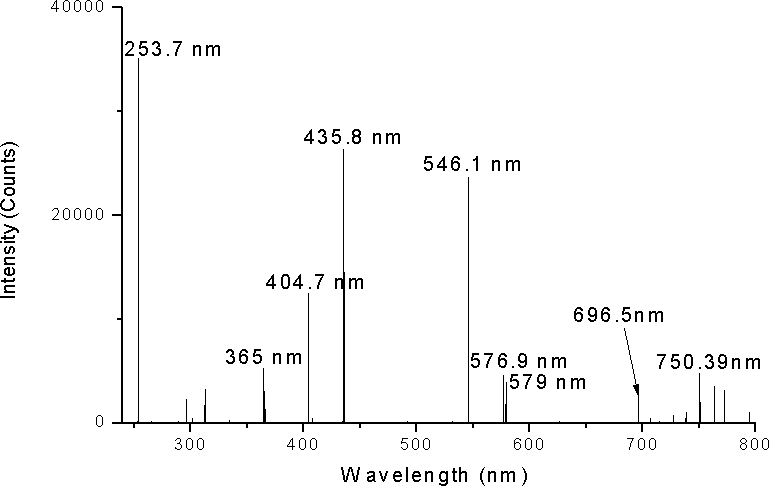

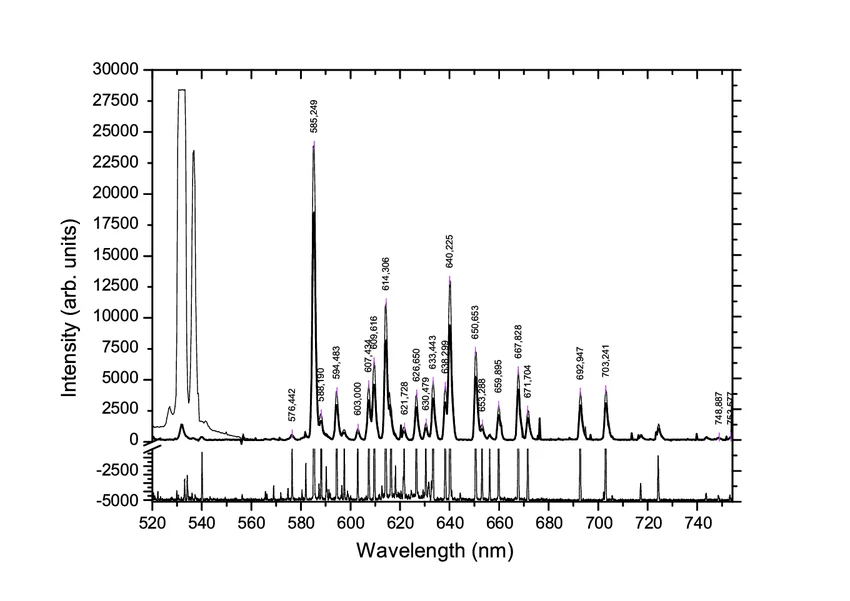

## HgAr

In [ ]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

%cd
%cd Desktop/software/captures
%cd hgar
%pwd

biases = np.zeros((1216, 1936, len(os.listdir('bias'))))
for i, bias in enumerate(os.listdir('bias')):
    bias_path = os.path.join('bias', bias)
    biases[:,:,i] = (fits.open(bias_path)[0].data)

bias_median = np.median(biases, axis=2)

darks = np.zeros((1216, 1936, len(os.listdir('dark_50000'))))
for i, dark in enumerate(os.listdir('dark_50000')):
    dark_path = os.path.join('dark_50000', dark)
    darks[:,:,i] = (fits.open(dark_path)[0].data) - bias_median

dark_median = np.median(darks, axis=2)



sciences = np.zeros((1216, 1936, len(os.listdir('science_50000'))))
for i, science in enumerate(os.listdir('science_50000')):
    science_path = os.path.join('science_50000', science)
    sciences[:,:,i] = (fits.open(science_path)[0].data)

science_median = np.median(sciences, axis=2)


# quick visual check
plt.figure(figsize=(8,5))
plt.imshow(science_median - dark_median, cmap='gray', origin='lower')
plt.colorbar(label='ADU')
plt.title('Master dark (median)')
plt.show()

final_im = science_median - dark_median

spectra(final_im)

In [ ]:
%pwd
%cd /Users/lalyboyer/Desktop/software/captures/

In [ ]:
# with fits.open(f"neon/capture_5000_20260625_161145.fits") as hdul: # open fits file
#         neon = hdul[0].data
        # header = hdul[0].header

with fits.open(f"LAMP_HGNE/SCIENCE_10000/SCIENCE_20260626_171957.627_6.fits") as hdul: # open fits file
        hgne = hdul[0].data
        header = hdul[0].header

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

im = ax.imshow(hgne, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"{OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red